In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
print("NumPy:", np.__version__)
print("Matplotlib imported successfully")

NumPy: 2.5.3
Matplotlib imported successfully


## 4.1 Closed-form

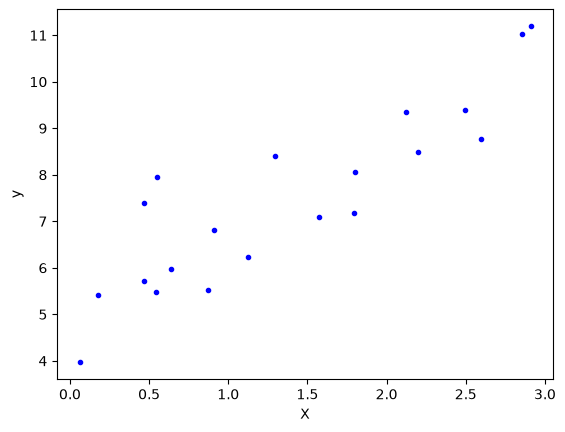

In [51]:
np.random.seed(42)

X = 3 * np.random.rand(20, 1)
y = 5 + 2 * X + np.random.randn(20, 1)

plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [52]:
X_1 = np.c_[X, np.ones((20, 1))]

print("X shape:", X.shape)
print("X_1 shape:", X_1.shape)
print(X_1[:5])

X shape: (20, 1)
X_1 shape: (20, 2)
[[1.12362036 1.        ]
 [2.85214292 1.        ]
 [2.19598183 1.        ]
 [1.79597545 1.        ]
 [0.46805592 1.        ]]


In [ ]:
w = np.linalg.inv(X_1.T.dot(X_1)).dot(X_1.T).dot(y)

print("Closed-form w:")
print(w)
print("w shape:", w.shape)

w =
[[1.82782176]
 [4.963605  ]]
w shape: (2, 1)


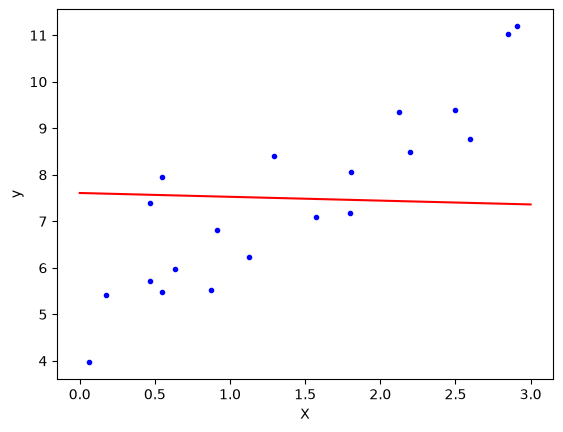

In [23]:
X_new = np.array([[0], [3]])
X_new_1 = np.c_[X_new, np.ones((2, 1))]
y_predict = X_new_1.dot(w)

plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [39]:
x_test = np.array([[2]])
x_test_1 = np.c_[x_test, np.ones((1, 1))]
y_test = x_test_1.dot(w)

print("Prediction for x=2:", y_test)

Prediction for x=2: [[7.44463179]]


In [26]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print("intercept:", lin_reg.intercept_)
print("coef:", lin_reg.coef_)

intercept: [4.963605]
coef: [[1.82782176]]


## 4.2 Gradient Descent Solution

In [48]:
alpha = 0.1
max_iterations = 1000
m = 20
w_gd = np.random.randn(2, 1)

print("initial w:")
print(w_gd)

initial w:
[[ 0.2088636 ]
 [-1.95967012]]


In [49]:
for iteration in range(max_iterations):
    gradients = 2 / m * X_1.T.dot(X_1.dot(w_gd) - y)
    w_gd = w_gd - alpha * gradients

print("Gradient Descent w:")
print(w_gd)

print("Closed-form w:")
print(w)

Gradient Descent w:
[[1.82782176]
 [4.963605  ]]
Closed-form w:
[[1.82782176]
 [4.963605  ]]


## 4.3 SGDRegressor

In [50]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    penalty=None,
    eta0=0.1
)

sgd_reg.fit(X, y.ravel())

print("SGD intercept:", sgd_reg.intercept_)
print("SGD coef:", sgd_reg.coef_)

SGD intercept: [4.89798325]
SGD coef: [1.90791252]
